In [992]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [993]:
df = pd.read_csv('Datasets\Banking Customer Churn Prediction Datasets.csv') 

<>:1: SyntaxWarning: invalid escape sequence '\B'
<>:1: SyntaxWarning: invalid escape sequence '\B'
C:\Users\DELL\AppData\Local\Temp\ipykernel_19076\2650144982.py:1: SyntaxWarning: invalid escape sequence '\B'
  df = pd.read_csv('Datasets\Banking Customer Churn Prediction Datasets.csv')


In [994]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [995]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


# Cheack null values



In [996]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

# Cheak Duplicate values

In [997]:
df.duplicated().sum()

np.int64(0)

# Drop irrelevant Fetures

In [998]:
df =  df.drop(['RowNumber','CustomerId','Surname','Geography'], axis=1)

In [999]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0


In [1000]:
df.corr(numeric_only=True)*100 

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
CreditScore,100.000000,-0.396491,0.084194,0.626838,1.223788,-0.545848,2.565132,-0.138429,-2.709354
Age,-0.396491,100.000000,-0.999683,2.830837,-3.068009,-1.172103,8.547215,-0.720104,28.532304
Tenure,0.084194,-0.999683,100.000000,-1.225393,1.344376,2.258287,-2.836208,0.778383,-1.400061
Balance,0.626838,2.830837,-1.225393,100.000000,-30.417974,-1.485834,-1.008410,1.279750,11.853277
NumOfProducts,1.223788,-3.068009,1.344376,-30.417974,100.000000,0.318315,0.961188,1.420420,-4.781986
HasCrCard,-0.545848,-1.172103,2.258287,-1.485834,0.318315,100.000000,-1.186564,-0.993341,-0.713777
IsActiveMember,2.565132,8.547215,-2.836208,-1.008410,0.961188,-1.186564,100.000000,-1.142143,-15.612828
EstimatedSalary,-0.138429,-0.720104,0.778383,1.279750,1.420420,-0.993341,-1.142143,100.000000,1.209686
Exited,-2.709354,28.532304,-1.400061,11.853277,-4.781986,-0.713777,-15.612828,1.209686,100.000000


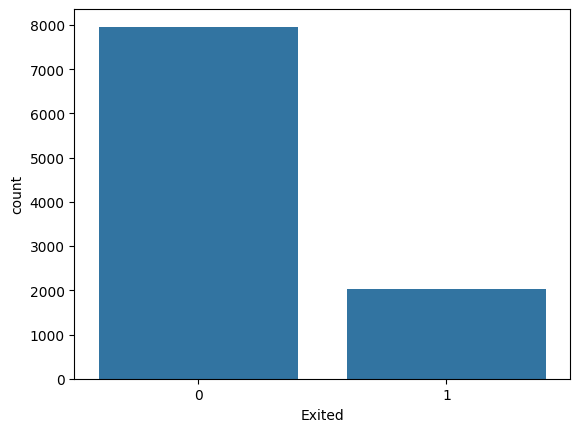

In [1001]:
sns.countplot(data=df,x='Exited')
plt.show()  

In [1002]:
df['Exited'].value_counts()

Exited
0    7963
1    2037
Name: count, dtype: int64

In [1003]:
x = df.drop('Exited', axis=1)
y = df['Exited']

In [1004]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score


In [1005]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)

In [1006]:

numeric_features = x_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = x.select_dtypes(include=['object']).columns

In [1007]:
x_train

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
2151,753,Male,57,7,0.00,1,1,0,159475.08
8392,739,Male,32,3,102128.27,1,1,0,63981.37
5006,755,Female,37,0,113865.23,2,1,1,117396.25
4117,561,Male,37,5,0.00,2,1,0,83093.25
7182,692,Male,49,6,110540.43,2,0,1,107472.99
...,...,...,...,...,...,...,...,...,...
4555,688,Female,35,6,0.00,1,1,0,25488.43
4644,712,Male,74,5,0.00,2,0,0,151425.82
8942,667,Female,37,9,71786.90,2,1,1,67734.79
2935,687,Male,35,8,100988.39,2,1,0,22247.27


# Transform data

In [1008]:

transformer = ColumnTransformer(
    transformers=[
    ('ohe',OneHotEncoder(sparse_output=False,drop='first'),categorical_features),
    ('sc',StandardScaler(),numeric_features)
    
    ]   
,remainder='passthrough')

In [1009]:
rf = RandomForestClassifier(class_weight='balanced')


In [1010]:
pipeline  = Pipeline([
    ('transformer',transformer),
    ('classifier',rf)
])

In [1011]:
param_grid = {
    'classifier__n_estimators': [100,200,500],
    'classifier__max_depth': [5,10, 15,20],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1],
    'classifier__bootstrap': [True]
}

In [1012]:
from sklearn.model_selection import RandomizedSearchCV

pipe = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    random_state=42,
    n_jobs=-1,
)

pipe.fit(x_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...'balanced'))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__bootstrap': [True], 'classifier__max_depth': [5, 10, ...], 'classifier__min_samples_leaf': [1], 'classifier__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategie

In [1013]:
print("Best Parameters:")
print(pipe.best_params_)

Best Parameters:
{'classifier__n_estimators': 500, 'classifier__min_samples_split': 2, 'classifier__min_samples_leaf': 1, 'classifier__max_depth': 20, 'classifier__bootstrap': True}


In [1014]:
y_pred = pipe.predict(x_test)

In [1015]:
accuracy_score(y_test,y_pred) * 100

85.05

In [1016]:
test_acc  = accuracy_score(y_test, y_pred) * 100
train_acc = pipe.score(x_train, y_train) * 100
print(f"Train accuracy : {train_acc:.2f}%")
print(f"Test  accuracy : {test_acc:.2f}%")
print(f"Gap            : {train_acc - test_acc:.2f}%")


Train accuracy : 100.00%
Test  accuracy : 85.05%
Gap            : 14.95%


In [1017]:
from sklearn.metrics import classification_report

In [1018]:

report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.86      0.96      0.91      1593
           1       0.74      0.41      0.53       407

    accuracy                           0.85      2000
   macro avg       0.80      0.69      0.72      2000
weighted avg       0.84      0.85      0.83      2000



In [1019]:
from sklearn.metrics import roc_auc_score

y_prob = pipe.predict_proba(x_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

from sklearn.metrics import log_loss

y_proba = pipe.predict_proba(x_test)
loss = log_loss(y_test, y_proba)
print("Log Loss:", loss)

ROC-AUC: 0.8408300442198747
Log Loss: 0.3584364142429957


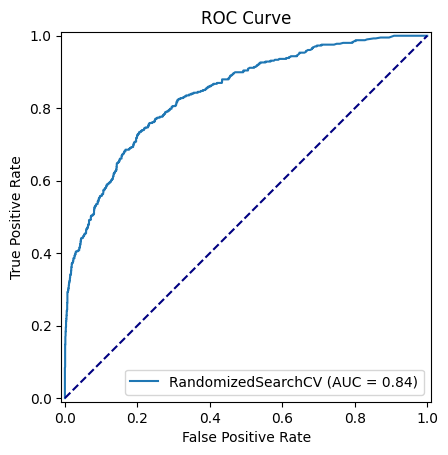

In [1020]:
from sklearn.metrics import RocCurveDisplay

# 1. Plot the ROC curve directly from your pipeline and test data
RocCurveDisplay.from_estimator(pipe, x_test, y_test)

# 2. Add chart titles and labels
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

# 3. Add a diagonal reference line (representing random guessing)
plt.plot([0, 1], [0, 1], color="navy", linestyle="--")

# 4. Display the chart
plt.show()
